# MAE Demo — ViT-Base / ViT-Large / ViT-Huge

**Masked Autoencoders Are Scalable Vision Learners** (He et al., 2022)

Notebook này demo cả 3 variant MAE:

| Variant | Encoder | Decoder | Patch | Grid | Params | Checkpoint |
|---------|---------|---------|-------|------|--------|------------|
| **ViT-Base** | 768d, 12 blocks, 12 heads | 512d, 8 blocks, 16 heads | 16×16 | 14×14 | ~112M | `mae_visualize_vit_base.pth` |
| **ViT-Large** | 1024d, 24 blocks, 16 heads | 512d, 8 blocks, 16 heads | 16×16 | 14×14 | ~330M | `mae_visualize_vit_large.pth` |
| **ViT-Huge** | 1280d, 32 blocks, 16 heads | 512d, 8 blocks, 16 heads | 14×14 | 16×16 | ~657M | `mae_visualize_vit_huge.pth` |

> **Về Checkpoints:**
> 
> Facebook chỉ release full checkpoint (encoder+decoder) cho **ViT-Large** (`mae_visualize_vit_large.pth`).
> Với Base và Huge, Facebook chỉ release pretrain checkpoint (encoder-only).
> 
> Tuy nhiên, **HuggingFace** host full pretrained weights (encoder+decoder) cho cả 3 variant:
> - `facebook/vit-mae-base` — ViT-Base full
> - `facebook/vit-mae-large` — ViT-Large full
> - `facebook/vit-mae-huge` — ViT-Huge full
> 
> Script `convert_hf_to_mae.py` convert từ HuggingFace format → Facebook format,
> cho phép load bằng `load_pretrained()`. Kết quả: **tất cả 3 variant đều reconstruct tốt!**

## 1. Setup

In [1]:
import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Ensure project root is in path
sys.path.insert(0, os.path.abspath('.'))

from models import mae_vit_base_patch16, mae_vit_large_patch16, mae_vit_huge_patch14

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name()}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU: NVIDIA GeForce RTX 3060
VRAM: 12.5 GB


## 2. Tạo và Load 3 Models

In [2]:
# Paths to FULL checkpoints (encoder + decoder)
# Large: original Facebook visualize checkpoint
# Base, Huge: converted from HuggingFace (facebook/vit-mae-base, facebook/vit-mae-huge)
#   via convert_hf_to_mae.py
CKPT_DIR = 'checkpoints/official_checkpoints'
ckpt_paths = {
    'Base':  os.path.join(CKPT_DIR, 'mae_visualize_vit_base.pth'),    # HF-converted (254 keys)
    'Large': os.path.join(CKPT_DIR, 'mae_visualize_vit_large.pth'),   # Facebook original (398 keys)
    'Huge':  os.path.join(CKPT_DIR, 'mae_visualize_vit_huge.pth'),    # HF-converted (494 keys)
}

# Create models
print('Creating models...')
models = {
    'Base':  mae_vit_base_patch16(),
    'Large': mae_vit_large_patch16(),
    'Huge':  mae_vit_huge_patch14(),
}

# Load full pretrained weights (encoder + decoder)
print()
for name, model in models.items():
    path = ckpt_paths[name]
    print(f'--- {name} ({os.path.basename(path)}) ---')
    missing, unexpected = model.load_pretrained(path)
    if missing:
        print(f'  ⚠️  Missing keys: {len(missing)}')
    model.eval()
    model.to(device)
    print()

Creating models...

--- Base (mae_visualize_vit_base.pth) ---
✅ Loaded FULL checkpoint (254 keys)

--- Large (mae_visualize_vit_large.pth) ---
✅ Loaded FULL checkpoint (398 keys)

--- Huge (mae_visualize_vit_huge.pth) ---
✅ Loaded FULL checkpoint (494 keys)


OutOfMemoryError: CUDA out of memory. Tried to allocate 26.00 MiB (GPU 0; 11.62 GiB total capacity; 3.36 GiB already allocated; 73.12 MiB free; 3.44 GiB reserved in total by PyTorch) If reserved memory is >> allocated memory try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF

## 3. Chuẩn bị ảnh

Loaded image from URL: https://upload.wikimedia.org/wikipedia/commons/thumb/3/3a/Ca...
Tensor shape: torch.Size([1, 3, 224, 224])


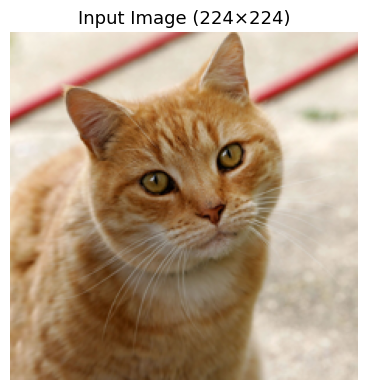

In [ ]:
def prepare_image(source='url', url=None, path=None, img_size=224):
    """
    Load và preprocess ảnh thành tensor (1, 3, 224, 224) ImageNet-normalized.
    source: 'url', 'file', hoặc 'synthetic'
    """
    imagenet_mean = np.array([0.485, 0.456, 0.406])
    imagenet_std = np.array([0.229, 0.224, 0.225])

    if source == 'url':
        import urllib.request
        if url is None:
            url = 'https://upload.wikimedia.org/wikipedia/commons/thumb/3/3a/Cat03.jpg/1200px-Cat03.jpg'
        try:
            req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
            img = Image.open(urllib.request.urlopen(req, timeout=10))
            print(f'Loaded image from URL: {url[:60]}...')
        except Exception as e:
            print(f'URL failed ({e}), falling back to synthetic image')
            return prepare_image(source='synthetic', img_size=img_size)
    elif source == 'file':
        img = Image.open(path)
        print(f'Loaded image from: {path}')
    else:
        # Synthetic gradient image
        arr = np.zeros((img_size, img_size, 3), dtype=np.uint8)
        for i in range(img_size):
            for j in range(img_size):
                arr[i, j] = [int(255 * i / img_size), int(255 * j / img_size), 128]
        img = Image.fromarray(arr)
        print('Using synthetic gradient image')

    img = img.convert('RGB').resize((img_size, img_size))
    img_np = np.array(img) / 255.0
    img_normalized = (img_np - imagenet_mean) / imagenet_std
    img_tensor = torch.tensor(img_normalized, dtype=torch.float32)
    img_tensor = img_tensor.permute(2, 0, 1).unsqueeze(0)  # (1, 3, 224, 224)

    return img_tensor, img_np

img_tensor, img_np = prepare_image(source='url')
img_tensor = img_tensor.to(device)
print(f'Tensor shape: {img_tensor.shape}')

plt.figure(figsize=(4, 4))
plt.imshow(img_np)
plt.title('Input Image (224×224)', fontsize=13)
plt.axis('off')
plt.tight_layout()
plt.show()

## 4. Visualization — Masking & Reconstruction

In [ ]:
imagenet_mean = np.array([0.485, 0.456, 0.406])
imagenet_std = np.array([0.229, 0.224, 0.225])

def run_mae(model, img_tensor, mask_ratio=0.75):
    """Forward pass qua MAE, trả về loss, pred, mask."""
    with torch.no_grad():
        loss, pred, mask = model(img_tensor, mask_ratio=mask_ratio)
    return loss.item(), pred, mask

def visualize_mae(model, img_tensor, img_np, mask_ratio=0.75, title_prefix=''):
    """
    Visualize 4 panel: Original | Masked | Reconstruction | Visible + Recon.
    Tự detect patch_size từ model.
    """
    loss, pred, mask = run_mae(model, img_tensor, mask_ratio)
    
    # Unpatchify
    pred_img = model.unpatchify(pred)
    pred_img = pred_img[0].permute(1, 2, 0).cpu().numpy()
    pred_img = pred_img * imagenet_std + imagenet_mean
    pred_img = np.clip(pred_img, 0, 1)
    
    # Grid info
    p = model.patch_size
    h = w = 224 // p
    
    # Create mask image
    mask_2d = mask[0].cpu().numpy().reshape(h, w)
    mask_img = np.ones_like(img_np)
    for i in range(h):
        for j in range(w):
            if mask_2d[i, j] == 1:  # masked
                mask_img[i*p:(i+1)*p, j*p:(j+1)*p] = 0.7  # gray
            else:  # visible
                mask_img[i*p:(i+1)*p, j*p:(j+1)*p] = img_np[i*p:(i+1)*p, j*p:(j+1)*p]
    
    # Visible + reconstruction composite
    composite = np.copy(pred_img)
    for i in range(h):
        for j in range(w):
            if mask_2d[i, j] == 0:  # visible → use original
                composite[i*p:(i+1)*p, j*p:(j+1)*p] = img_np[i*p:(i+1)*p, j*p:(j+1)*p]
    
    # Plot
    fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
    titles = ['Original', f'Masked ({mask_ratio*100:.0f}%)', 'Reconstruction', 'Visible + Recon']
    images = [img_np, mask_img, pred_img, composite]
    
    for ax, img, t in zip(axes, images, titles):
        ax.imshow(img)
        ax.set_title(t, fontsize=12)
        ax.axis('off')
    
    fig.suptitle(f'{title_prefix} — MSE Loss: {loss:.4f}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return loss

### 4.1 ViT-Base (full checkpoint — HuggingFace converted)

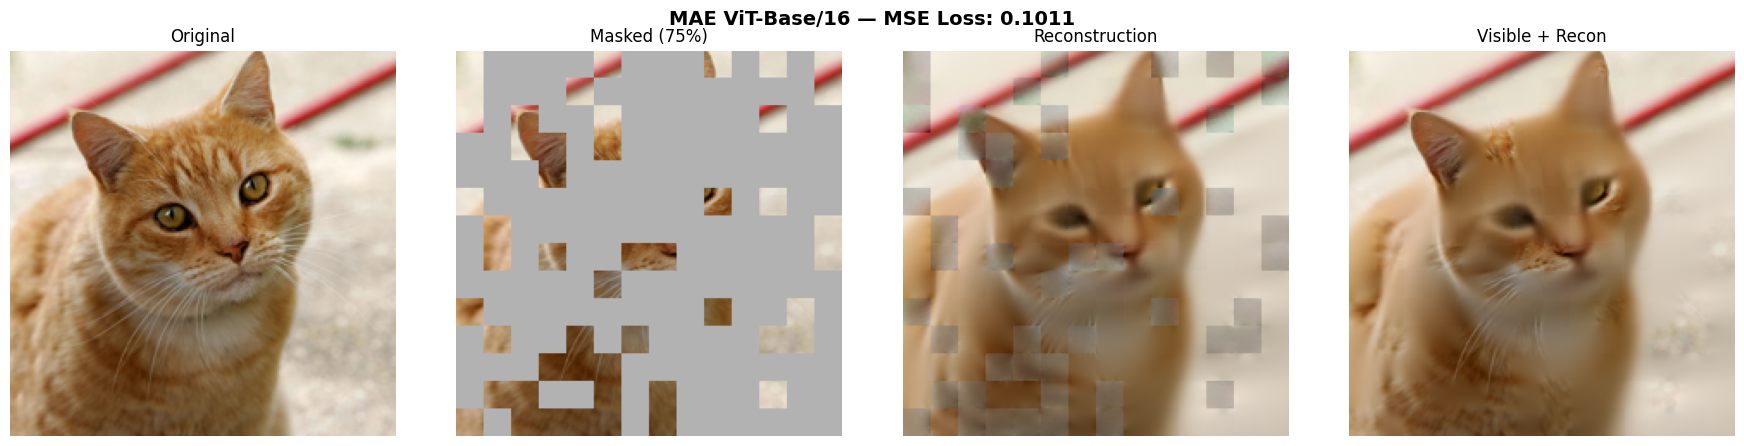

✅ Full checkpoint (HuggingFace → Facebook format via convert_hf_to_mae.py)


In [ ]:
loss_base = visualize_mae(models['Base'], img_tensor, img_np, title_prefix='MAE ViT-Base/16')
print(f'✅ Full checkpoint (HuggingFace → Facebook format via convert_hf_to_mae.py)')

### 4.2 ViT-Large (full checkpoint — Facebook original)

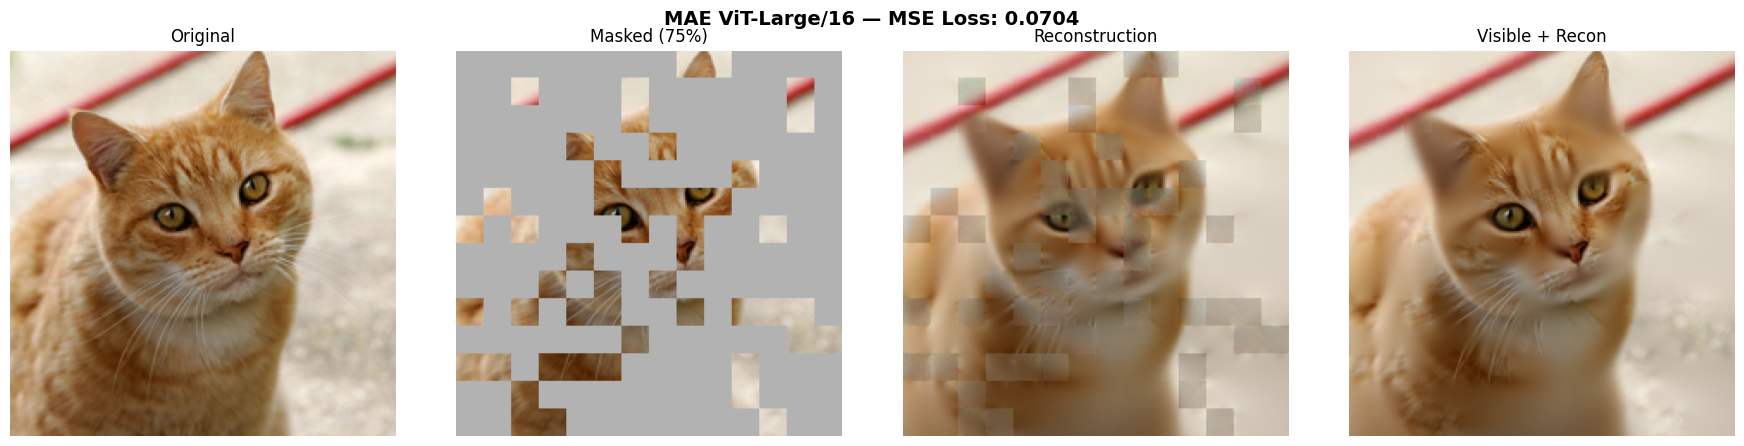

✅ Full checkpoint (Facebook original mae_visualize_vit_large.pth)


In [ ]:
loss_large = visualize_mae(models['Large'], img_tensor, img_np, title_prefix='MAE ViT-Large/16')
print(f'✅ Full checkpoint (Facebook original mae_visualize_vit_large.pth)')

### 4.3 ViT-Huge (full checkpoint — HuggingFace converted)

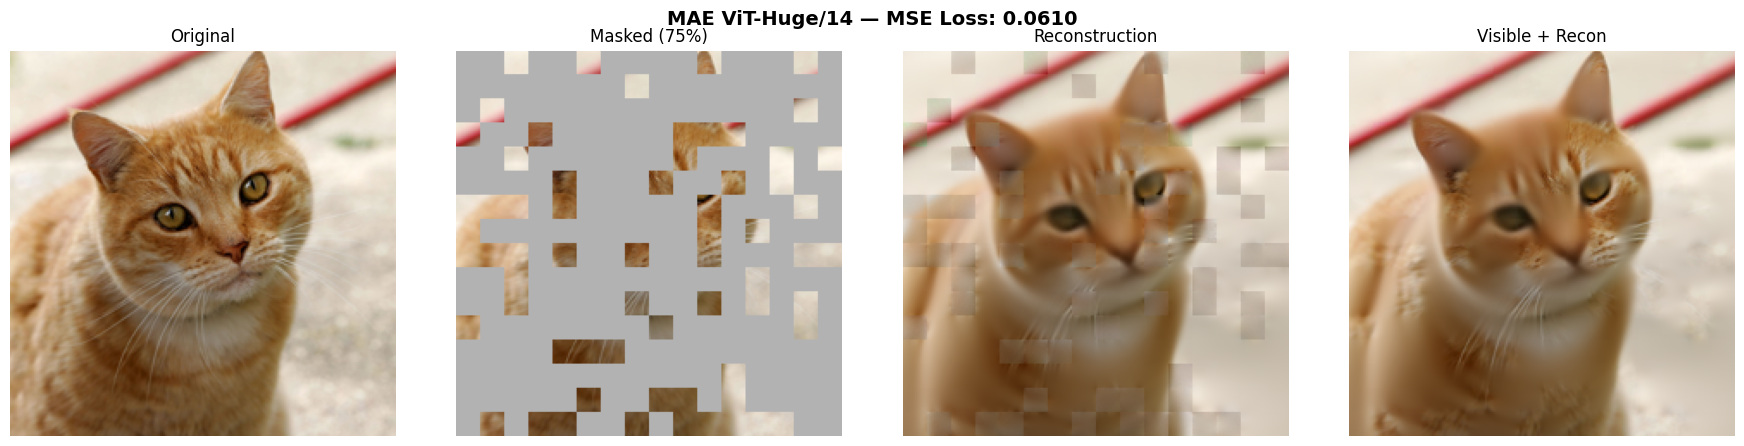

✅ Full checkpoint (HuggingFace → Facebook format via convert_hf_to_mae.py)
📐 patch_size=14, grid=16×16 (256 patches) — khác Base/Large (patch_size=16, 14×14, 196 patches)


In [ ]:
loss_huge = visualize_mae(models['Huge'], img_tensor, img_np, title_prefix='MAE ViT-Huge/14')
print(f'✅ Full checkpoint (HuggingFace → Facebook format via convert_hf_to_mae.py)')
print(f'📐 patch_size=14, grid=16×16 (256 patches) — khác Base/Large (patch_size=16, 14×14, 196 patches)')

## 5. So sánh Mask Ratio — ViT-Large (Full Checkpoint)

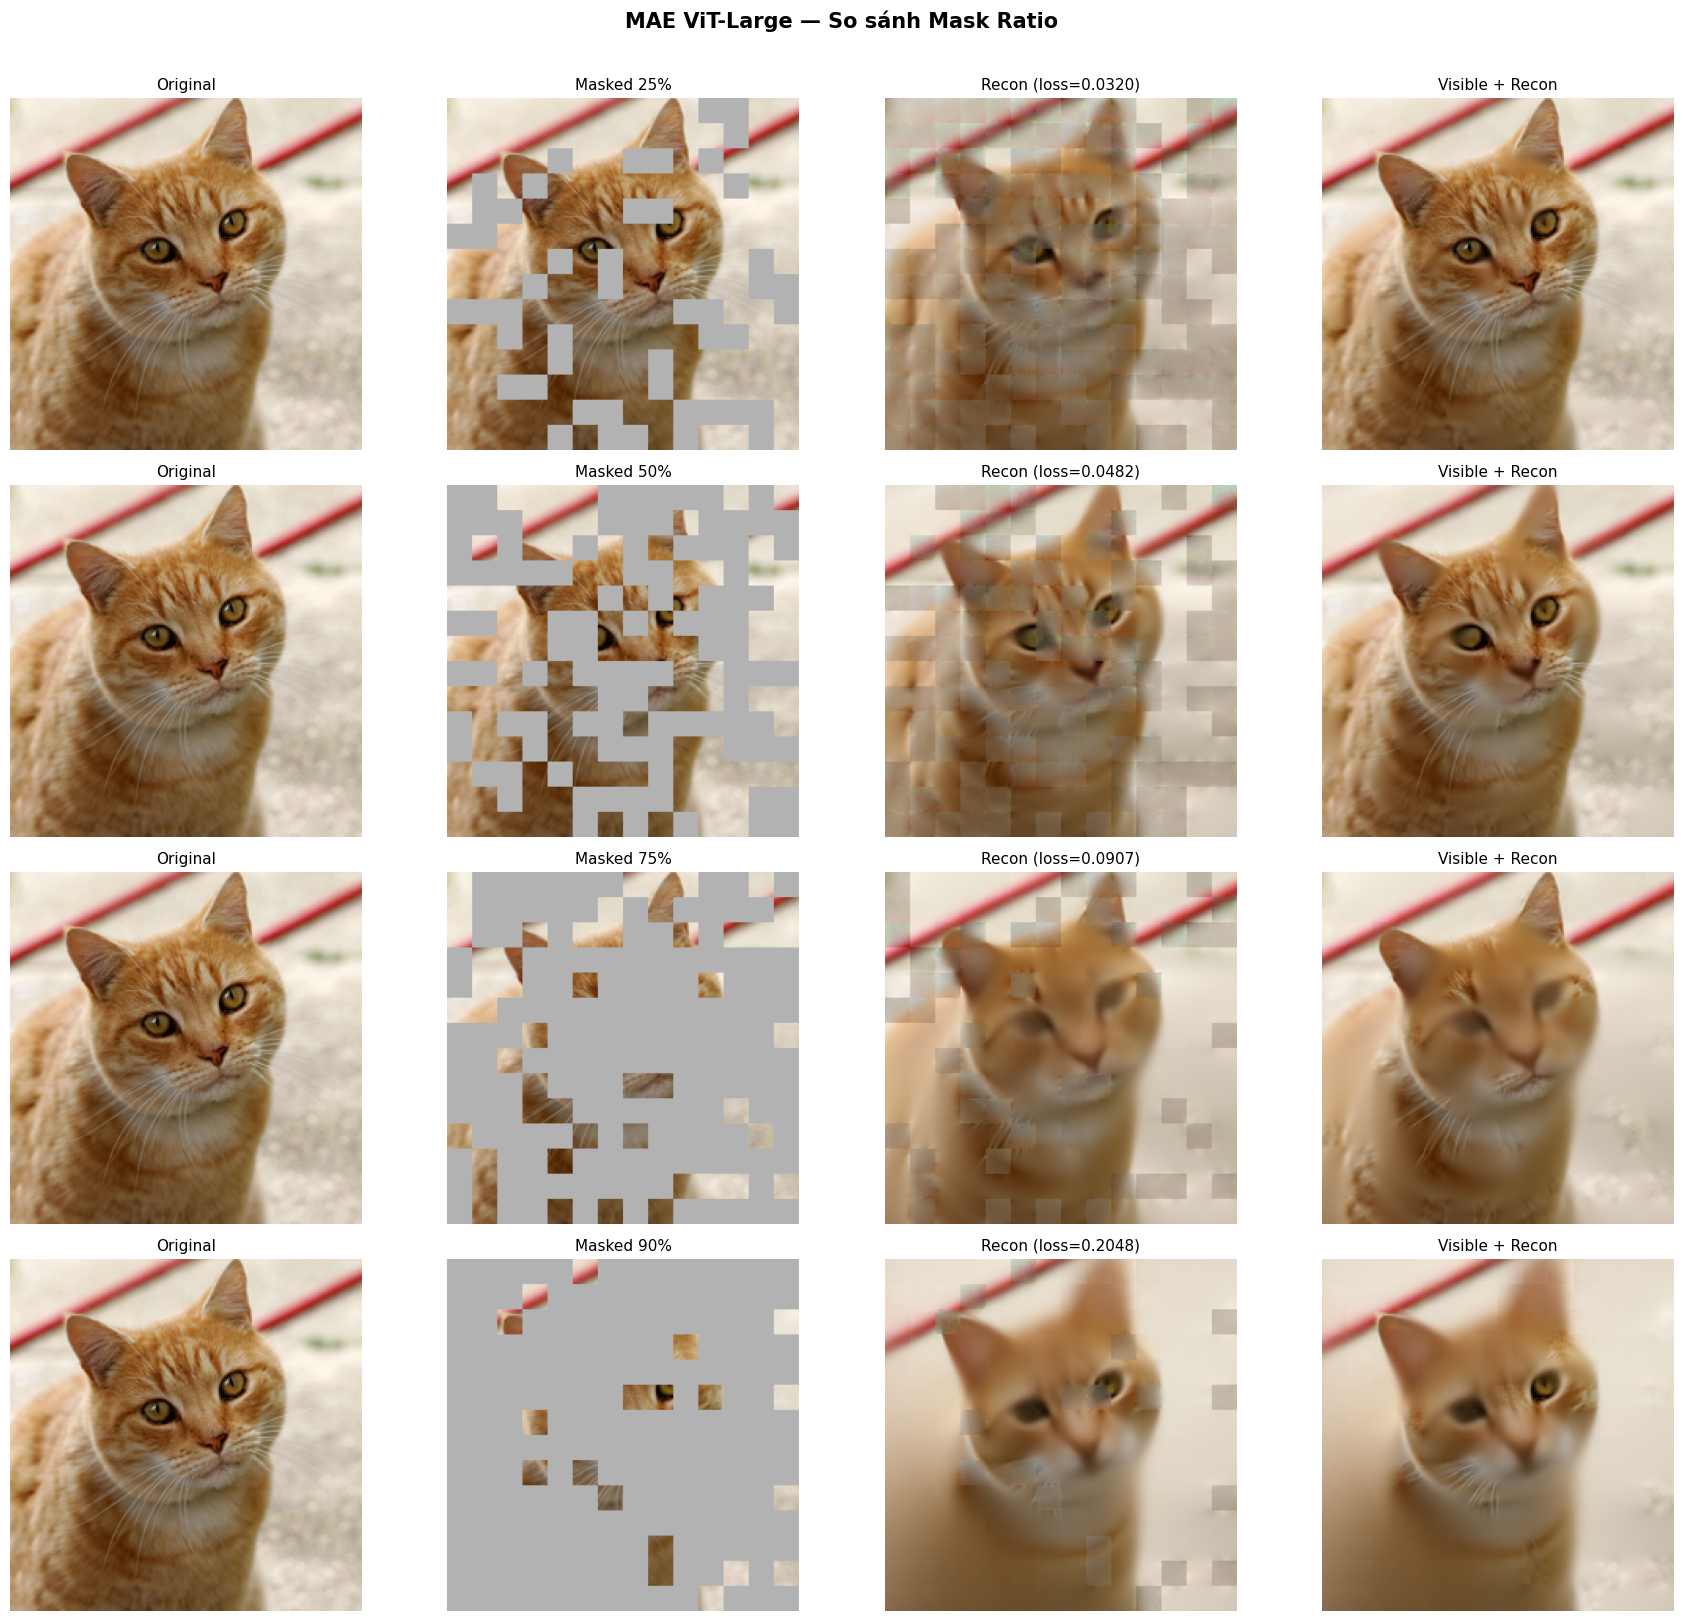

In [ ]:
mask_ratios = [0.25, 0.50, 0.75, 0.90]

fig, axes = plt.subplots(len(mask_ratios), 4, figsize=(18, 4 * len(mask_ratios)))

for row, ratio in enumerate(mask_ratios):
    with torch.no_grad():
        loss, pred, mask = models['Large'](img_tensor, mask_ratio=ratio)
    
    pred_img = models['Large'].unpatchify(pred)
    pred_img = pred_img[0].permute(1, 2, 0).cpu().numpy()
    pred_img = np.clip(pred_img * imagenet_std + imagenet_mean, 0, 1)
    
    p = 16  # Large patch_size
    h = w = 14
    mask_2d = mask[0].cpu().numpy().reshape(h, w)
    
    mask_img = np.ones_like(img_np)
    composite = np.copy(pred_img)
    for i in range(h):
        for j in range(w):
            if mask_2d[i, j] == 1:
                mask_img[i*p:(i+1)*p, j*p:(j+1)*p] = 0.7
            else:
                mask_img[i*p:(i+1)*p, j*p:(j+1)*p] = img_np[i*p:(i+1)*p, j*p:(j+1)*p]
                composite[i*p:(i+1)*p, j*p:(j+1)*p] = img_np[i*p:(i+1)*p, j*p:(j+1)*p]
    
    for col, (img_data, title) in enumerate([
        (img_np, 'Original'),
        (mask_img, f'Masked {ratio*100:.0f}%'),
        (pred_img, f'Recon (loss={loss.item():.4f})'),
        (composite, 'Visible + Recon'),
    ]):
        axes[row, col].imshow(img_data)
        axes[row, col].set_title(title, fontsize=11)
        axes[row, col].axis('off')

fig.suptitle('MAE ViT-Large — So sánh Mask Ratio', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 6. Mask Pattern Comparison (Base vs Large vs Huge)

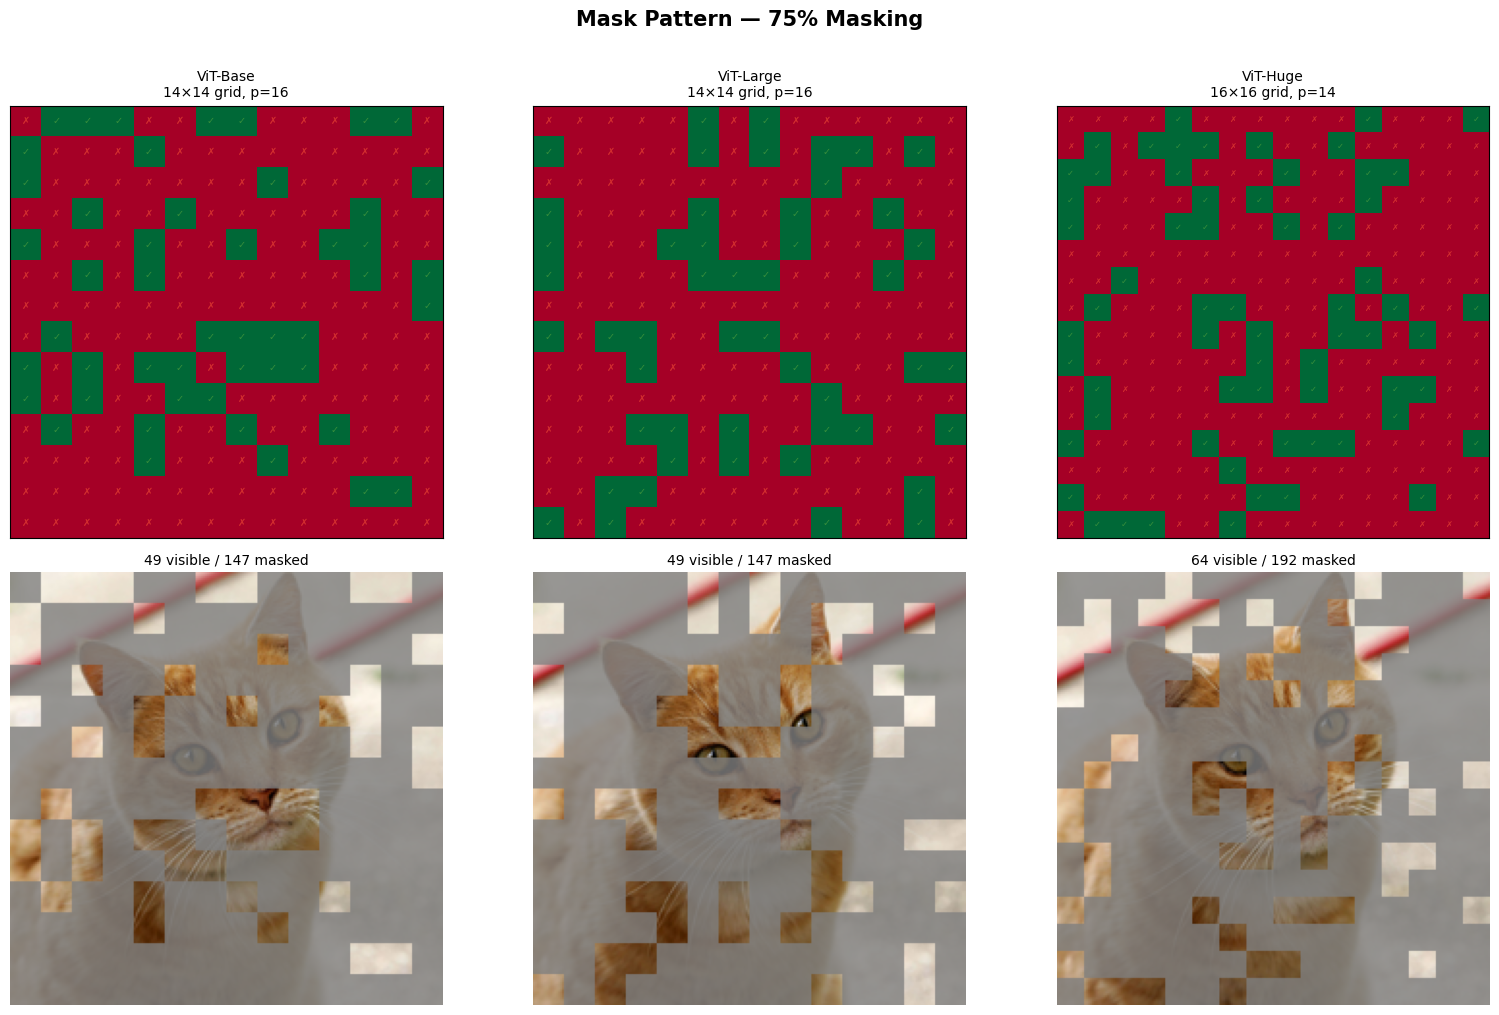

In [ ]:
def visualize_mask_pattern(model, img_tensor, title, ax_grid, ax_overlay, img_np):
    """Vẽ mask pattern (grid + overlay) cho 1 model."""
    with torch.no_grad():
        _, mask, _ = model.forward_encoder(img_tensor, mask_ratio=0.75)
    
    p = model.patch_size
    h = w = 224 // p
    mask_2d = mask[0].cpu().numpy().reshape(h, w)
    
    # Grid pattern
    ax_grid.imshow(1 - mask_2d, cmap='RdYlGn', vmin=0, vmax=1)
    for i in range(h):
        for j in range(w):
            symbol = '✗' if mask_2d[i, j] == 1 else '✓'
            color = '#d32f2f' if mask_2d[i, j] == 1 else '#388e3c'
            fontsize = 6 if h >= 16 else 7
            ax_grid.text(j, i, symbol, ha='center', va='center',
                        fontsize=fontsize, color=color, fontweight='bold')
    ax_grid.set_title(f'{title}\n{h}×{w} grid, p={p}', fontsize=10)
    ax_grid.set_xticks([])
    ax_grid.set_yticks([])
    
    n_masked = int(mask_2d.sum())
    n_visible = h * w - n_masked
    
    # Overlay on image
    overlay = img_np.copy()
    for i in range(h):
        for j in range(w):
            if mask_2d[i, j] == 1:
                overlay[i*p:(i+1)*p, j*p:(j+1)*p] = \
                    overlay[i*p:(i+1)*p, j*p:(j+1)*p] * 0.2 + 0.5 * 0.8
    ax_overlay.imshow(overlay)
    ax_overlay.set_title(f'{n_visible} visible / {n_masked} masked', fontsize=10)
    ax_overlay.axis('off')

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for col, (name, model) in enumerate(models.items()):
    visualize_mask_pattern(model, img_tensor, f'ViT-{name}',
                          axes[0, col], axes[1, col], img_np)

fig.suptitle('Mask Pattern — 75% Masking', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 7. Model Summary — So sánh 3 Variants

In [3]:
def count_params(model, prefix=''):
    """Đếm params theo prefix."""
    return sum(p.numel() for n, p in model.named_parameters() if n.startswith(prefix))

print('=' * 80)
print(f'{"":>20} {"ViT-Base":>15} {"ViT-Large":>15} {"ViT-Huge":>15}')
print('=' * 80)

rows = [
    ('patch_size', lambda m: m.patch_size),
    ('grid', lambda m: f'{224//m.patch_size}×{224//m.patch_size}'),
    ('num_patches', lambda m: (224 // m.patch_size) ** 2),
    ('embed_dim (enc)', lambda m: m.encoder.blocks[0].attn.qkv.in_features),
    ('depth (enc)', lambda m: len(m.encoder.blocks)),
    ('num_heads (enc)', lambda m: m.encoder.blocks[0].attn.num_heads),
    ('embed_dim (dec)', lambda m: m.decoder.decoder_blocks[0].attn.qkv.in_features),
    ('depth (dec)', lambda m: len(m.decoder.decoder_blocks)),
    ('Encoder params', lambda m: f'{count_params(m, "encoder.") / 1e6:.1f}M'),
    ('Decoder params', lambda m: f'{count_params(m, "decoder.") / 1e6:.1f}M'),
    ('Total params', lambda m: f'{sum(p.numel() for p in m.parameters()) / 1e6:.1f}M'),
    ('Model size (MB)', lambda m: f'{sum(p.numel() * p.element_size() for p in m.parameters()) / 1e6:.0f}'),
]

for label, fn in rows:
    vals = [str(fn(models[n])) for n in ['Base', 'Large', 'Huge']]
    print(f'{label:>20} {vals[0]:>15} {vals[1]:>15} {vals[2]:>15}')

print('=' * 80)

# Checkpoint info — now all full!
ckpt_info = {
    'Base':  'full (HF) ',
    'Large': 'full (FB) ',
    'Huge':  'full (HF) ',
}
vals = [ckpt_info[n] for n in ['Base', 'Large', 'Huge']]
print(f'{"Checkpoint":>20} {vals[0]:>15} {vals[1]:>15} {vals[2]:>15}')
print('=' * 80)
print()
print('HF = HuggingFace (facebook/vit-mae-*), converted via convert_hf_to_mae.py')
print('FB = Facebook original mae_visualize_vit_large.pth')
print('All 3 variants now have full encoder+decoder weights → good reconstruction!')

                            ViT-Base       ViT-Large        ViT-Huge
          patch_size              16              16              14
                grid           14×14           14×14           16×16
         num_patches             196             196             256
     embed_dim (enc)             768            1024            1280
         depth (enc)              12              24              32
     num_heads (enc)              12              16              16
     embed_dim (dec)             512             512             512
         depth (dec)               8               8               8
      Encoder params           85.8M          303.3M          630.8M
      Decoder params           26.1M           26.2M           26.3M
        Total params          111.9M          329.5M          657.1M
     Model size (MB)             448            1318            2628
          Checkpoint      full (HF)       full (FB)       full (HF) 

HF = HuggingFace (facebook/vit-ma

## 8. Parameter Distribution — Charts

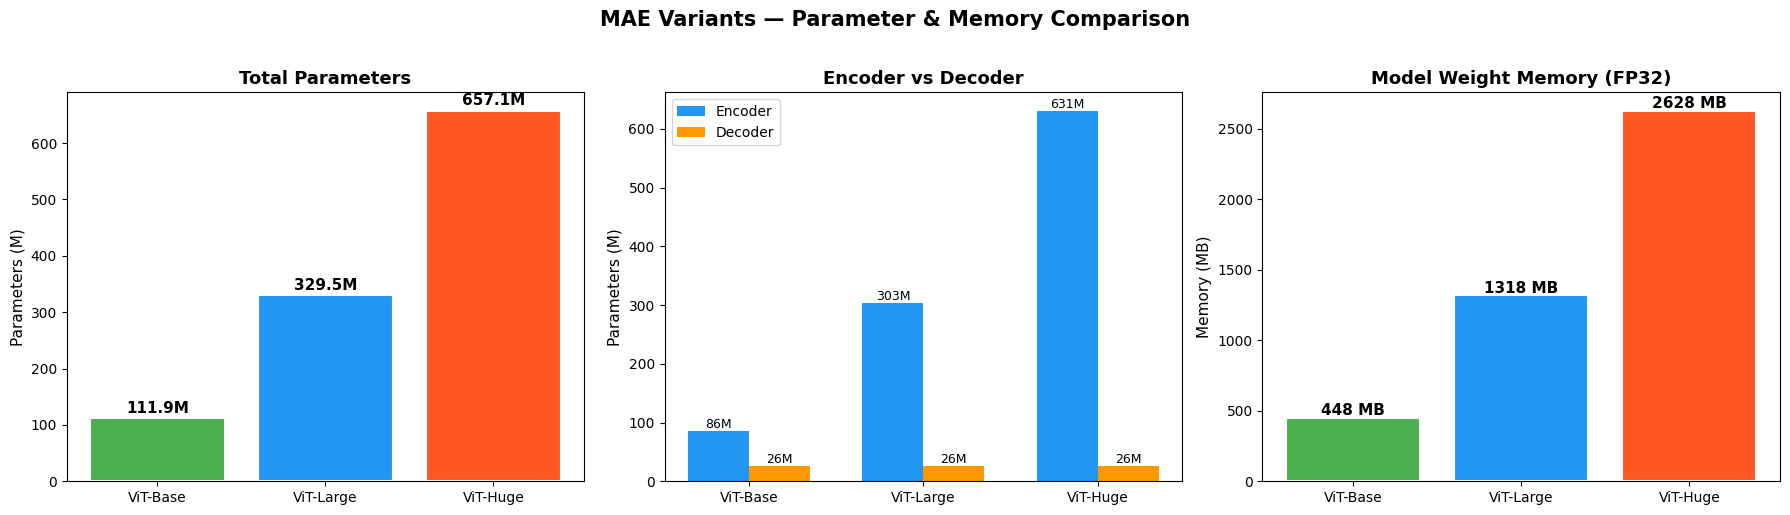

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Chart 1: Total params comparison ---
names = ['ViT-Base', 'ViT-Large', 'ViT-Huge']
total_params = [sum(p.numel() for p in models[n].parameters()) / 1e6 for n in ['Base', 'Large', 'Huge']]
colors = ['#4CAF50', '#2196F3', '#FF5722']

bars = axes[0].bar(names, total_params, color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, total_params):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
                f'{val:.1f}M', ha='center', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Parameters (M)', fontsize=11)
axes[0].set_title('Total Parameters', fontsize=13, fontweight='bold')

# --- Chart 2: Encoder vs Decoder breakdown ---
enc_params = [count_params(models[n], 'encoder.') / 1e6 for n in ['Base', 'Large', 'Huge']]
dec_params = [count_params(models[n], 'decoder.') / 1e6 for n in ['Base', 'Large', 'Huge']]

x = np.arange(len(names))
w = 0.35
bars1 = axes[1].bar(x - w/2, enc_params, w, label='Encoder', color='#2196F3')
bars2 = axes[1].bar(x + w/2, dec_params, w, label='Decoder', color='#FF9800')
axes[1].set_xticks(x)
axes[1].set_xticklabels(names)
axes[1].set_ylabel('Parameters (M)', fontsize=11)
axes[1].set_title('Encoder vs Decoder', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)

for bar in bars1:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{bar.get_height():.0f}M', ha='center', fontsize=9)
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{bar.get_height():.0f}M', ha='center', fontsize=9)

# --- Chart 3: Memory estimation (FP32, inference bs=1) ---
mem_params = [sum(p.numel() * p.element_size() for p in models[n].parameters()) / 1e6
              for n in ['Base', 'Large', 'Huge']]

bars = axes[2].bar(names, mem_params, color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, mem_params):
    axes[2].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
                f'{val:.0f} MB', ha='center', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Memory (MB)', fontsize=11)
axes[2].set_title('Model Weight Memory (FP32)', fontsize=13, fontweight='bold')

fig.suptitle('MAE Variants — Parameter & Memory Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 9. Encoder Feature Analysis — 3 Variants

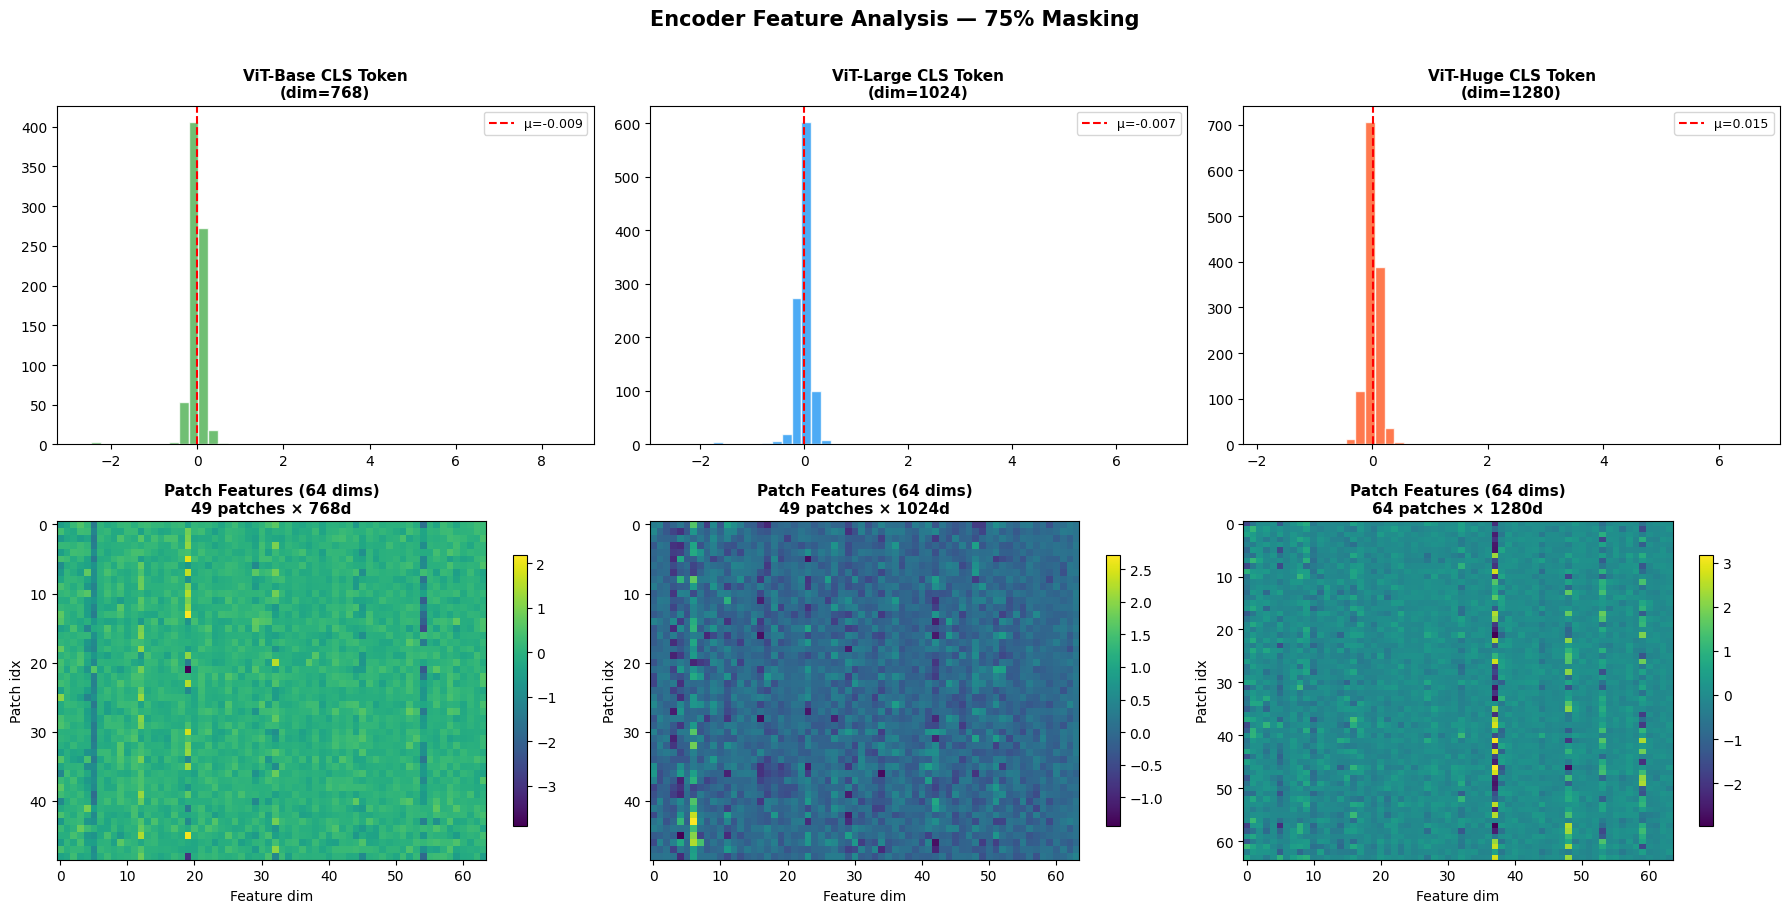

ViT- Base: latent=torch.Size([1, 50, 768])  (14×14=196 patches, 49 visible, 147 masked)
ViT-Large: latent=torch.Size([1, 50, 1024])  (14×14=196 patches, 49 visible, 147 masked)
ViT- Huge: latent=torch.Size([1, 65, 1280])  (16×16=256 patches, 64 visible, 192 masked)


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))

for col, (name, model) in enumerate(models.items()):
    with torch.no_grad():
        latent, mask, ids_restore = model.forward_encoder(img_tensor, mask_ratio=0.75)
    
    cls_token = latent[0, 0, :].cpu().numpy()
    patch_features = latent[0, 1:, :].cpu().numpy()  # (N_vis, D)
    
    # Row 1: CLS token distribution
    axes[0, col].hist(cls_token, bins=50, color=colors[col], alpha=0.8, edgecolor='white')
    axes[0, col].set_title(f'ViT-{name} CLS Token\n(dim={len(cls_token)})', fontsize=11, fontweight='bold')
    axes[0, col].axvline(cls_token.mean(), color='red', linestyle='--',
                         label=f'μ={cls_token.mean():.3f}')
    axes[0, col].legend(fontsize=9)
    
    # Row 2: Feature heatmap (first 64 dims)
    heatmap = patch_features[:, :64]
    im = axes[1, col].imshow(heatmap, aspect='auto', cmap='viridis')
    axes[1, col].set_title(f'Patch Features (64 dims)\n{patch_features.shape[0]} patches × {patch_features.shape[1]}d',
                           fontsize=11, fontweight='bold')
    axes[1, col].set_xlabel('Feature dim')
    axes[1, col].set_ylabel('Patch idx')
    plt.colorbar(im, ax=axes[1, col], shrink=0.8)

fig.suptitle('Encoder Feature Analysis — 75% Masking', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Print encoder output shapes
for name, model in models.items():
    with torch.no_grad():
        latent, mask, _ = model.forward_encoder(img_tensor, mask_ratio=0.75)
    p = model.patch_size
    grid = 224 // p
    n_vis = latent.shape[1] - 1  # exclude CLS
    print(f'ViT-{name:>5}: latent={latent.shape}  '
          f'({grid}×{grid}={grid*grid} patches, {n_vis} visible, {grid*grid - n_vis} masked)')

## 10. GPU VRAM Usage

In [ ]:
if device.type == 'cuda':
    print('GPU VRAM Usage (all 3 models loaded):')
    print(f'  Allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB')
    print(f'  Reserved:  {torch.cuda.memory_reserved() / 1e9:.2f} GB')
    print(f'  Total:     {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
    print()
    
    # Per-model size
    for name in ['Base', 'Large', 'Huge']:
        size_mb = sum(p.numel() * p.element_size() for p in models[name].parameters()) / 1e6
        print(f'  ViT-{name:>5} weights: {size_mb:.0f} MB')
else:
    print('Running on CPU — no VRAM info available')

GPU VRAM Usage (all 3 models loaded):
  Allocated: 7.19 GB
  Reserved:  7.37 GB
  Total:     12.5 GB

  ViT- Base weights: 448 MB
  ViT-Large weights: 1318 MB
  ViT- Huge weights: 2628 MB


## 11. Tóm tắt

In [4]:
print()
print('=' * 70)
print('  MAE — 3 VARIANT SUMMARY')
print('=' * 70)
print(f'')
print(f'  Paper:  Masked Autoencoders Are Scalable Vision Learners')
print(f'  By:     He, Chen, Xie, Li, Dollár, Girshick (CVPR 2022)')
print(f'  Repo:   https://github.com/facebookresearch/mae')
print(f'')

for name in ['Base', 'Large', 'Huge']:
    m = models[name]
    p = m.patch_size
    grid = 224 // p
    enc_d = m.encoder.blocks[0].attn.qkv.in_features
    enc_b = len(m.encoder.blocks)
    total = sum(pp.numel() for pp in m.parameters()) / 1e6
    ckpt_file = os.path.basename(ckpt_paths[name])
    print(f'  ViT-{name:>5}:  {enc_d}d / {enc_b} blocks / p={p} / '
          f'{grid}×{grid}={grid*grid} patches / {total:.1f}M params')
    print(f'           → {ckpt_file} ')

print(f'')
print(f'  Input:       (B, 3, 224, 224) — ImageNet-normalized')
print(f'  Mask ratio:  75% (default)')
print(f'  LayerNorm:   eps=1e-6 (matching official implementation)')
print(f'')
print(f'  Checkpoints:')
print(f'    mae_visualize_vit_base.pth  — HuggingFace (full enc+dec, 254 keys)')
print(f'    mae_visualize_vit_large.pth — Facebook original (full enc+dec, 398 keys)')
print(f'    mae_visualize_vit_huge.pth  — HuggingFace (full enc+dec, 494 keys)')
print(f'')
print(f'  Convert script: convert_hf_to_mae.py')
print(f'    Merges HF separate Q,K,V → merged qkv matrix')
print(f'    Remaps key names to Facebook flat format')
print(f'')
print('=' * 70)
print('   All 3 variants loaded with full weights — reconstruction good!')
print('=' * 70)


  MAE — 3 VARIANT SUMMARY

  Paper:  Masked Autoencoders Are Scalable Vision Learners
  By:     He, Chen, Xie, Li, Dollár, Girshick (CVPR 2022)
  Repo:   https://github.com/facebookresearch/mae

  ViT- Base:  768d / 12 blocks / p=16 / 14×14=196 patches / 111.9M params
           → mae_visualize_vit_base.pth 
  ViT-Large:  1024d / 24 blocks / p=16 / 14×14=196 patches / 329.5M params
           → mae_visualize_vit_large.pth 
  ViT- Huge:  1280d / 32 blocks / p=14 / 16×16=256 patches / 657.1M params
           → mae_visualize_vit_huge.pth 

  Input:       (B, 3, 224, 224) — ImageNet-normalized
  Mask ratio:  75% (default)
  LayerNorm:   eps=1e-6 (matching official implementation)

  Checkpoints:
    mae_visualize_vit_base.pth  — HuggingFace (full enc+dec, 254 keys)
    mae_visualize_vit_large.pth — Facebook original (full enc+dec, 398 keys)
    mae_visualize_vit_huge.pth  — HuggingFace (full enc+dec, 494 keys)

  Convert script: convert_hf_to_mae.py
    Merges HF separate Q,K,V → merged 